# 5 — Bancada de exploração

Notebook de trabalho: a célula abaixo deixa tudo carregado e pronto. Diferente dos notebooks
1–4, aqui nada é definitivo — é onde testamos ideias antes de decidir o que vira análise.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 50)

from src.utils import load_config
from src import antenna

CIDADE = "campinas"
config = load_config(CIDADE)
config["spatial"]["download_basemap"] = True

edges_antenna = pd.read_parquet(ROOT / config["data"]["edges_antenna_path"])
antennas = pd.read_parquet(ROOT / config["data"]["antennas_path"])

net   = antenna.build(edges_antenna, antennas, config)
nodes = net.nodes          # uma linha por região
flows = net.flows          # uma linha por par de regiões conectado
G     = net.G              # grafo não-direcionado ponderado
D     = net.D              # versão dirigida
B     = net.backbone       # backbone por filtro de disparidade

cm = antenna.build_contact_matrix(edges_antenna, nodes)   # matriz do paper
K, J = cm.K, cm.J

print(f"{net.n_antennas} regiões | {G.number_of_edges():,} fluxos | {nodes['n_users'].sum():,} moradores")
print(f"objetos prontos: nodes, flows, G, D, B, cm, K, J")

145 regiões | 5,817 fluxos | 25,176 moradores
objetos prontos: nodes, flows, G, D, B, cm, K, J


## Atalhos úteis

Mapa temático de qualquer coluna de `nodes` (usa as células de Voronoi):

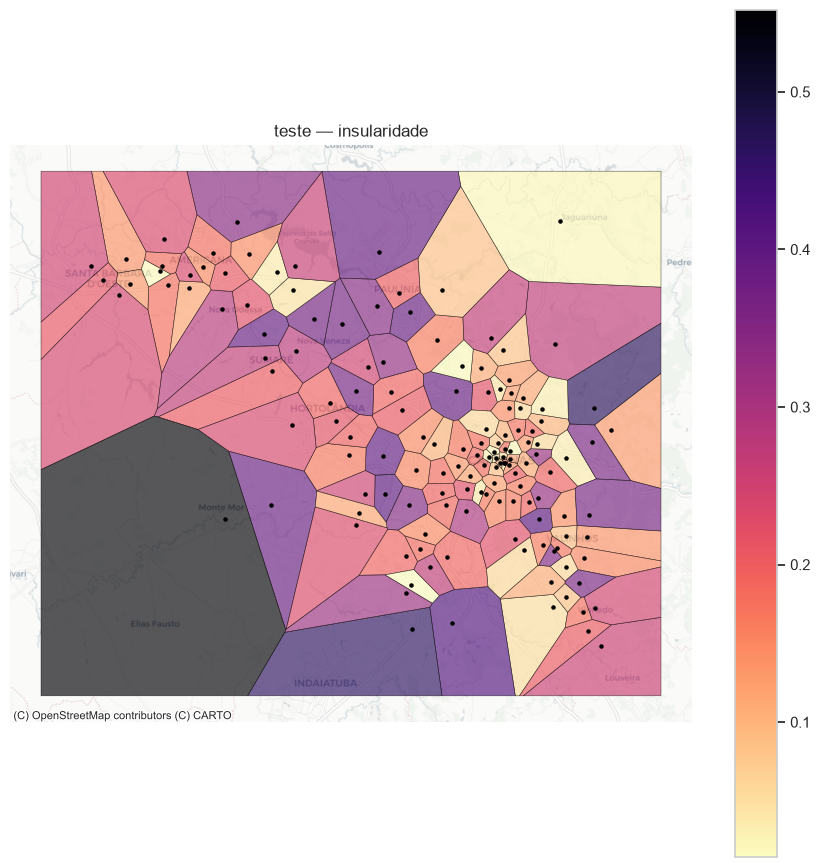

In [2]:
from src.pipeline.spatial import _build_gdf, _build_voronoi, _add_basemap

gdf = _build_gdf(nodes)
vor = _build_voronoi(gdf)


def mapa(coluna, titulo=None, cmap="viridis", categorico=False, centro=None, dados=None):
    """Pinta as regiões por uma coluna. `dados` permite passar uma Series indexada por antenna_id."""
    v = vor.copy()
    if dados is not None:
        v[coluna] = v["antenna_id"].map(dados)
    fig, ax = plt.subplots(figsize=(11, 11))
    kw = dict(column=coluna, cmap=cmap, legend=True, edgecolor="black",
              linewidth=0.4, alpha=0.65, ax=ax)
    if categorico:
        kw["categorical"] = True
    elif centro is not None:
        s = v[coluna].dropna()
        span = max(abs(s.min() - centro), abs(s.max() - centro))
        kw.update(vmin=centro - span, vmax=centro + span)
    v.plot(**kw)
    gdf.plot(ax=ax, color="black", markersize=5)
    _add_basemap(ax, config)
    ax.set_axis_off()
    ax.set_title(titulo or coluna)
    plt.show()


mapa("insularity", "teste — insularidade", cmap="magma_r")

## Espaço de trabalho

A partir daqui é livre.

In [3]:
nodes.head()

,antenna_id,residence_city,residence_quintile_state,residence_quintile_nation,lon,lat,n_users,calls_out,duration_out,calls_in,duration_in,calls_internal,duration_internal,calls_total,calls_external,insularity,net_balance,calls_per_user
0,22,Campinas,q5,q5,-47.04919,-22.93991,228,7550,10557.19,5914,11188.04,1919,3629.34,11545,9626,0.166219,0.121509,50.635965
1,52,Campinas,q4,q4,-47.01132,-22.80971,81,2347,5365.33,2010,3451.97,930,1145.17,3427,2497,0.271374,0.077347,42.308642
2,275,Campinas,q5,q5,-47.14177,-22.78256,117,3389,3833.74,3478,4619.79,1907,1830.03,4960,3053,0.384476,-0.012961,42.393162
3,312,Campinas,q1,q2,-47.15887,-22.84911,343,8687,17615.56,8666,17573.95,2826,3290.89,14527,11701,0.194534,0.001210,42.352770
4,321,Campinas,q5,q5,-47.07153,-22.84958,217,4934,7698.98,5091,7124.22,1796,2081.70,8229,6433,0.218253,-0.015661,37.921659
